In [1]:
import pandas as pd
import numpy as np

stops = pd.read_csv("Delivery_Stops.csv")
depot = pd.read_csv("Depot.csv")

stops = stops.sort_values("Dispatch_Order").reset_index(drop=True)
print(stops)
print(depot)

   Stop_ID            Customer_Name   Latitude  Longitude  Dispatch_Order
0     D-09           École Ste-Anne  48.166145 -79.002108               1
1     D-15  Bibliothèque Municipale  48.225917 -79.044797               2
2     D-19       Résidence Bouchard  48.292290 -79.004658               3
3     D-14       Atelier Métal Plus  48.248425 -78.993181               4
4     D-18      Boulangerie Artisan  48.241689 -78.963873               5
5     D-06             Café Central  48.255118 -79.119114               6
6     D-03         Dépanneur du Lac  48.205467 -78.968010               7
7     D-21    Librairie du Quartier  48.193311 -78.935629               8
8     D-01       Tremblay Résidence  48.218731 -79.031031               9
9     D-02            Bureau Nordik  48.194017 -79.017195              10
10    D-13         Épicerie du Coin  48.187982 -78.991188              11
11    D-07        Boucherie St-Jean  48.241316 -79.036387              12
12    D-17  Salon Coiffure Élégance  4

In [3]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth's radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

In [4]:
def route_distance(stops_df, depot_df):
    depot_pt = (depot_df["Latitude"][0], depot_df["Longitude"][0])
    points = [depot_pt] + list(zip(stops_df["Latitude"], stops_df["Longitude"])) + [depot_pt]
    total = 0
    for i in range(len(points) - 1):
        total += haversine(points[i][0], points[i][1], points[i+1][0], points[i+1][1])
    return total

naive_distance = route_distance(stops, depot)
print(f"Naive route distance: {naive_distance:.2f} km")

Naive route distance: 130.73 km


In [5]:
def nearest_neighbor_route(stops_df, depot_df):
    depot_pt = (depot_df["Latitude"][0], depot_df["Longitude"][0])
    remaining = stops_df.copy().reset_index(drop=True)
    current = depot_pt
    route_order = []

    while len(remaining) > 0:
        dists = remaining.apply(lambda row: haversine(current[0], current[1], row["Latitude"], row["Longitude"]), axis=1)
        nearest_idx = dists.idxmin()
        nearest_stop = remaining.loc[nearest_idx]
        route_order.append(nearest_stop)
        current = (nearest_stop["Latitude"], nearest_stop["Longitude"])
        remaining = remaining.drop(nearest_idx)

    return pd.DataFrame(route_order).reset_index(drop=True)

optimized_stops = nearest_neighbor_route(stops, depot)
optimized_distance = route_distance(optimized_stops, depot)
print(f"Optimized route distance: {optimized_distance:.2f} km")

reduction_pct = (1 - optimized_distance / naive_distance) * 100
print(f"Reduction: {reduction_pct:.1f}%")

Optimized route distance: 75.37 km
Reduction: 42.3%


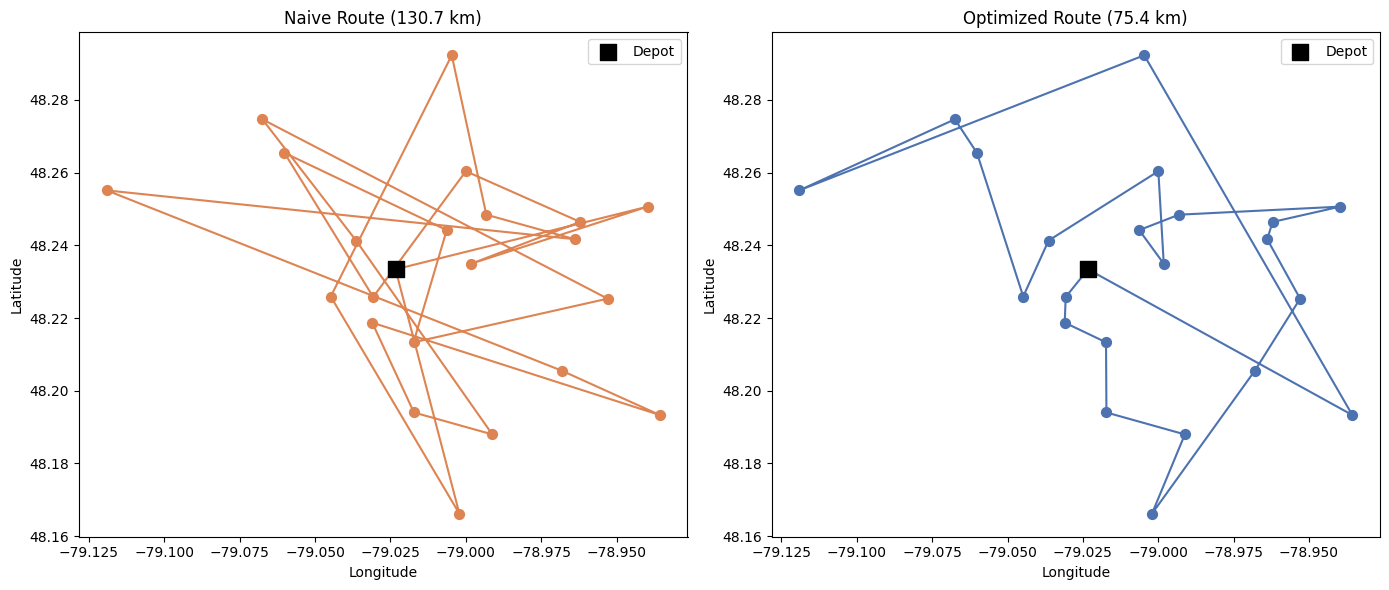

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

depot_lat, depot_lon = depot["Latitude"][0], depot["Longitude"][0]

def plot_route(ax, route_df, title, color):
    lats = [depot_lat] + list(route_df["Latitude"]) + [depot_lat]
    lons = [depot_lon] + list(route_df["Longitude"]) + [depot_lon]
    ax.plot(lons, lats, '-', color=color, linewidth=1.5, zorder=1)
    ax.scatter(route_df["Longitude"], route_df["Latitude"], color=color, s=50, zorder=2)
    ax.scatter([depot_lon], [depot_lat], color="black", marker="s", s=120, zorder=3, label="Depot")
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend()

plot_route(axes[0], stops, f"Naive Route ({naive_distance:.1f} km)", "#DD8452")
plot_route(axes[1], optimized_stops, f"Optimized Route ({optimized_distance:.1f} km)", "#4C72B0")

plt.tight_layout()
plt.savefig("route_comparison.png", dpi=150)
plt.show()